# Fase 2 - Actividad 4: Diseño del Pipeline de Integración (Submuestreo + Vectorización)

1. **Submuestreo (Undersampling):** Balanceo de las clases primero, para igualar la representación de clases y reducir masivamente la carga de procesamiento.
2. **Vectorización:** Transformación del texto a formato numérico usando TF-IDF. Al hacerlo en este orden, los pesos IDF (Inverse Document Frequency) se calculan en un mundo perfectamente balanceado, evitando el sesgo estadístico hacia la clase mayoritaria.

In [2]:


import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

## 1. Carga del Dataset de Entrenamiento/Validación


In [3]:
input_path = 'data/train_val_set.csv'
df_train_val = pd.read_csv(input_path, sep=';')

print(f"Total de registros cargados: {df_train_val.shape[0]}")
display(df_train_val.head())

Total de registros cargados: 45784


,id,label,texto_beto,texto_lineal
0,37365,1,Las bases de Bcomú apoyan por gran mayoría un ...,bases bcomú apoyan gran mayoría pacto psc voto...
1,26891,1,El PSOE acusa a la presidenta del Congreso de ...,psoe acusa presidenta congreso bloquear renova...
2,52932,0,José Antonio Griñán aboga por la devolución de...,josé antonio griñán aboga devolución menores m...
3,21014,1,Imputado el director del máster de Cifuentes E...,imputado director máster cifuentes enrique álv...
4,40069,0,Carlos Prieto vuelve a eludir su responsabilid...,carlos prieto vuelve eludir responsabilidad re...


Aislamos las características ($X$) como un DataFrame 2D (necesario para el submuestreo) y la variable objetivo ($y$). Usaremos la columna `texto_lineal`.

In [4]:
df_train_val['texto_lineal'] = df_train_val['texto_lineal'].fillna('')
X = df_train_val[['texto_lineal']] # Mantenemos X como DataFrame para nombrar columnas
y = df_train_val['label']

print("Distribución original de clases en entrenamiento:")
print(y.value_counts(normalize=True) * 100)

Distribución original de clases en entrenamiento:
label
1    58.273633
0    41.726367
Name: proportion, dtype: float64


## 2. Construcción Arquitectónica del Pipeline

Para evitar el sesgo estadístico y el colapso de RAM, el pipeline seguirá este orden:
1. **`RandomUnderSampler`**: Equilibra las clases 50/50 descartando ejemplos de la clase mayoritaria.
2. **`ColumnTransformer` + `TfidfVectorizer`**: Aplica la vectorización exclusivamente sobre la columna `texto_lineal` de los textos *ya filtrados*. Esto asegura que los pesos IDF nazcan matemáticamente puros.


In [5]:
# 1. Vectorizador envuelto en un ColumnTransformer para manejar el DataFrame resultante del submuestreo
preprocessor = ColumnTransformer(
    transformers=[
        ('tfidf', TfidfVectorizer(max_features=5000), 'texto_lineal')
    ]
)

# 2. Submuestreador (Se ejecuta primero en el pipeline)
undersampler = RandomUnderSampler(random_state=42)

# 3. Ensamblaje del Pipeline (Orden crítico: Undersampler -> Vectorizer)
pipeline = Pipeline(steps=[
    ('undersampler', undersampler),
    ('vectorizer', preprocessor)
])

pipeline

,steps,"[('undersampler', ...), ('vectorizer', ...)]"
,transform_input,None
,memory,None
,verbose,False
,random_state,42
,sampling_strategy,'auto'
,replacement,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('tfidf', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None


## 3. Demostración Práctica (Sin Fuga de Datos)

Para comprobar la lógica, se ejecuta una prueba única sobre los datos usando `.fit_transform()`. Al tratarse del pipeline completo donde la vectorización está al final, esto ejecutará el submuestreo y luego calculará los valores TF-IDF para la matriz equilibrada.


--- Después del Pipeline ---
Dimensión de la matriz generada: (38208, 5000)

Distribución de clases del vector resultante:
label
0    19104
1    19104
Name: count, dtype: int64


C:\Users\Baller 293\AppData\Local\Temp\ipykernel_18192\40457519.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_resampled, palette='viridis')


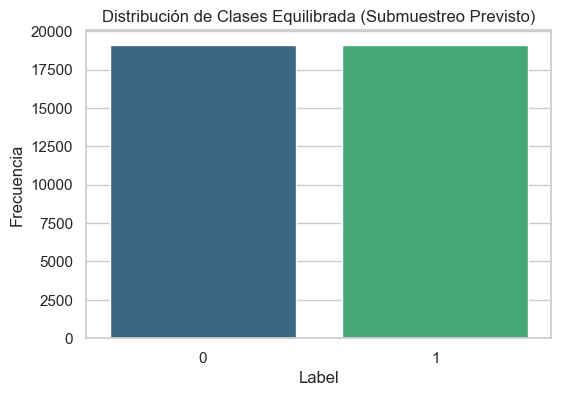

In [6]:
X_transformado = pipeline.fit_transform(X, y)

print("\n--- Después del Pipeline ---")
print(f"Dimensión de la matriz generada: {X_transformado.shape}")

idx_resampled = pipeline.named_steps['undersampler'].sample_indices_
y_resampled = y.iloc[idx_resampled]

print("\nDistribución de clases del vector resultante:")
print(y_resampled.value_counts())

# Gráfica de la distribución tras el resampleo
plt.figure(figsize=(6,4))
sns.countplot(x=y_resampled, palette='viridis')
plt.title('Distribución de Clases Equilibrada (Submuestreo Previsto)')
plt.xlabel('Label')
plt.ylabel('Frecuencia')
plt.show()